In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Set up simulation

In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [12]:
SOC_0 = 1
SOC_name = '100A' #str(int(SOC_0*100))
Q_nom = 4.6
t_end = 15*60

# load data import ESC data from file
raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
data['Cell Temperature'][data['Cell Temperature']>140] = None
data.interpolate(inplace=True)
# data['Current Shunt'] = -data['Current Shunt']
data['Current Shunt'] = -(data['Current Shunt'] - np.mean(raw_data['Current Shunt'][0:esc_start]))
data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
df_labels = ['t', 'V', 'Temp','I', 'F']
data.set_axis(df_labels, axis=1, inplace=True)
data['I_C'] = data.I/Q_nom 
AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
data.reset_index(drop=True, inplace=True)
display(data)

,t,V,Temp,I,F,I_C,SOC
0,0.000,4.176052,24.111259,0.020091,0.000000,0.004368,0.999301
1,0.100,1.564826,24.140908,231.399794,0.603288,50.304303,0.997904
2,0.200,1.543099,24.121142,231.423703,0.698544,50.309501,0.996508
3,0.300,1.521092,24.150790,231.033186,1.174824,50.224606,0.995110
4,0.400,1.515830,24.121142,231.893918,1.174824,50.411721,0.993709
...,...,...,...,...,...,...,...
8996,899.602,0.019834,69.558434,1.347038,-125.515679,0.292834,0.346521
8997,899.702,0.019834,69.548850,1.358993,-125.388671,0.295433,0.346512
8998,899.802,0.019754,69.568017,1.474553,-125.642687,0.320555,0.346504
8999,899.902,0.019874,69.548850,1.339069,-125.198159,0.291102,0.346496


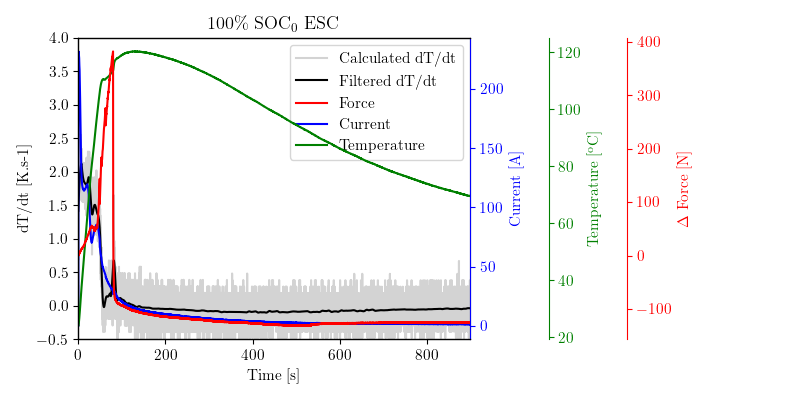

In [13]:
dTdt_data = np.diff(data.Temp)/np.diff(data.t)
# dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)
dT_filtered = signal.savgol_filter(data.Temp, 150,3, deriv=1)/signal.savgol_filter(data.t, 150,3, deriv=1)


# plot 
fig, ax= plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
# ax = ax.flatten()
p1, = ax.plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated dT/dt")
p2, = ax.plot(data.t, dT_filtered, color = 'k', label = "Filtered dT/dt")
ax.set_ylabel("dT/dt [K.s-1]")
ax.set_xlabel("Time [s]")
ax.set_ylim([-0.5, 4])
ax.set_xlim([0,t_end])

ax2 = ax.twinx()
p4, = ax2.plot(data.t, data.I, color = 'b', label = "Current")
ax2.set_ylabel('Current [A]')
ax2.yaxis.label.set_color(p4.get_color())
ax2.tick_params(axis='y', colors=p4.get_color())
ax2.spines.right.set_color(p4.get_color())

ax3 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.2))
p5, = ax3.plot(data.t, data.Temp, color = 'g', label = "Temperature")
ax3.set_ylabel("Temperature [$^\mathrm{o}$C]")
ax3.yaxis.label.set_color(p5.get_color())
ax3.tick_params(axis='y', colors=p5.get_color())
ax3.spines.right.set_color(p5.get_color())

ax1 = ax.twinx()
ax1.spines.right.set_position(("axes", 1.4))
p3, = ax1.plot(data.t, data.F, color = 'r', label = "Force")
ax1.set_ylabel("$\Delta$ Force [N]")
ax1.yaxis.label.set_color(p3.get_color())
ax1.tick_params(axis='y', colors=p3.get_color())
ax1.spines.right.set_color(p3.get_color())

plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")
ax.legend(handles=[p1, p2, p3, p4, p5], loc = "upper right")

# if SOC_0 ==1:
#     t_vap = [40, 80] #100%SOC
# elif SOC_0 ==0.75:
#     t_vap = [50, 110]#75%SOC
# else: 
#     t_vap = []
# for t in t_vap:
#     ylims = ax.get_ylim()
#     ax.plot([t]*2, list(ylims), color = 'r', linestyle = '--')
#     # axs.annotate('Venting', xy=(t_vap, np.diff(ylims)*0.25+ ylims[0]), rotation=-90, color = 'm')
#     ax.set_ylim(ylims) # keep original limits

# T_bps = [110]
# for T_bp in T_bps: 
#     t_boiling = data.t[(T_bp-data.Temp)<0.2].iloc[0]
#     ylims = ax.get_ylim()
#     ax.plot([t_boiling]*2, list(ylims), color = 'g', linestyle = ':')
#     ax.annotate('Boiling point', xy=(t_boiling, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'g')

plt.tight_layout()
plt.show()

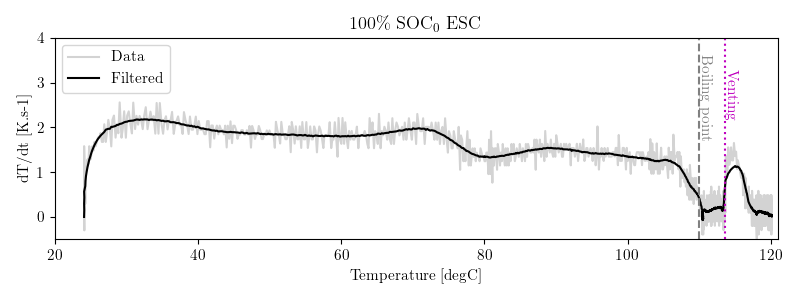

In [14]:
dTdt_data = np.diff(data.Temp)/np.diff(data.t)
dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

# plot 
t_plot_end = 120
fig, ax= plt.subplots(1, 1, figsize=(8, 3))
ax.plot(data.Temp[data.t<t_plot_end], dTdt_data[data.t[0:-1]<t_plot_end], color = "lightgrey", label = "Data")
ax.plot(data.Temp[data.t<t_plot_end], dT_filtered[data.t[0:-1]<t_plot_end], color = "k", label = "Filtered")
ax.set_xlabel("Temperature [degC]")
ax.set_ylabel("dT/dt [K.s-1]")
ax.legend()
ax.set_ylim([-0.5, 4])
ax.set_xlim([20,121])

plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")

T_bps = [110]

for T in T_bps:
    ylims = ax.get_ylim()
    ax.plot([T]*2, list(ylims), color = 'grey', linestyle = '--')
    ax.annotate('Boiling point', xy=(T, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'grey')
    ax.set_ylim(ylims) # keep original limits

if SOC_0 == 1: 
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    sigma_0 = param["Initial cell compression stress [kPa]"]
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
    T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
    ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = ':')
    ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.6+ ylims[0]), rotation=-90, color = 'm')
plt.tight_layout()
plt.show()

In [15]:
def OCV_dim(self, soc):
    inputs = {
        "SOC": soc,
    }
    return pybamm.FunctionParameter("Cell open circuit voltage [V]", inputs)

def ocv(soc):
    p0 = np.array([0.114319142120841,  -0.663997904709863, 
            1.686768366470837,  -2.462409468590447,   2.282769243949050, 
            -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
            0.027351974716897,  -0.002866912229499,   0.000171009483610,
            0.000029999998915])*1e5
    return np.polyval(p0,soc)

# Nondimensional

## Check that model runs

In [16]:
h = 15
Cp=1.2
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Cell open circuit voltage [V]": ocv,
    "Cell capacity [A.h]": 4.6, #nominal
    "Typical current [A]": 4.6,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
liion = pybamm.LithiumIonParameters()
tau_discharge = param.evaluate(liion.tau_discharge)
tau_th_yz = param.evaluate(liion.tau_th_yz)

In [17]:
def sim_thermal_nondim(h,Cp):    
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)


    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = data.I*(ocv(data.SOC)-data.V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L_x) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    for i,(t, q) in enumerate(zip(data.t[0:-1], Q_data[0:-1])):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale/C_th}
        sim.step(dt, external_variables=external_variables)
    return sim


# sim = sim_thermal_nondim(17.08215933, 1.2349498) #19.12756173,  1.18576391
# solution = sim.solution
# liion = pybamm.LithiumIonParameters()
# tau_discharge = param.evaluate(liion.tau_discharge)
# tau_th_yz = param.evaluate(liion.tau_th_yz)
# t_sol, y_sol = solution.t*tau_discharge, solution.y  # get solution times and states
# T = solution["Volume-averaged cell temperature [K]"]
# # Q = solution["Volume-averaged total heating"].entries

# # plot 
# Q_data = data.I*(ocv(data.SOC)-data.V)
# fig, ax= plt.subplots(1, 1, figsize=(4, 4))
# V_cell_norm = param.evaluate(liion.L_x) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
# ax.plot(data.t, data.Temp, label = "Data")
# # ax.plot(data.t, Q_data/V_cell_norm/Q_scale,label = "Data")
# # ax.plot(t_sol, Q, linestyle = '--',label =  "Model Q")
# ax.plot(data.t, T(data.t)-273.15, label =  "Model T")
# ax.set_xlabel("Time [s]")
# ax.legend()

# plt.tight_layout()
# plt.show()


## Set up loss function

In [18]:
T_bp = 107 #degC
if SOC_0 !=0.5: # doesn't get hot enough
    t_boiling = data.t[(T_bp-data.Temp)<0.2].iloc[0] 
def loss_T_nondim(k:np.ndarray): 
    h = k[0]
    Cp = k[1]
    solution = sim_thermal_nondim(h,Cp).solution

    # if SOC_0 ==1:
        # t_vap = [t_boiling, 90] #100%SOC
        # time_window = (data.t<t_vap[0]) | (data.t>t_vap[1])
        # time_window = data.Temp<110
    # w = (data.Temp.iloc[0:-1]<T_bp).astype(int) + 0.1*(data.Temp.iloc[0:-1]>T_bp).astype(int) # decrease weight while vaporizing
    w = (data.Temp<T_bp).astype(int) + 0.1*(data.Temp>T_bp).astype(int) # decrease weight while vaporizing
    t = data.t#.iloc[0:-1]
        # time_window_vap = data.Temp>110
    dTdt_data = np.diff(data.Temp.iloc[0:-1])/np.diff(data.t.iloc[0:-1])
    # elif SOC_0 ==0.75:
    #     t_vap = [50, 110]#75%SOC
    #     # time_window = (data.t<t_vap[0]) | (data.t>t_vap[1])
    #     time_window = data.Temp<110
    #     t = data.t[time_window].iloc[0:-1]
    #     dTdt_data = np.diff(data.Temp[time_window].iloc[0:-1])/np.diff(data.t[time_window].iloc[0:-1])
    # else: 
    #     dTdt_data = np.diff(data.Temp.iloc[0:-1])/np.diff(data.t.iloc[0:-1])
    #     t_vap = []
    # t = data.t[0:-1]
    # dTdt_data = np.diff(data.Temp[0:-1])/np.diff(data.t[0:-1])

    # calculate squared sum for rest period
    T = solution['Volume-averaged cell temperature [K]']
    loss_T = np.mean(np.square(data.Temp[0:-1]- (T(data.t[0:-1])-273.15))*w.iloc[0:-1])/np.mean(data.Temp[0:-1])
    # loss_T = np.linalg.norm(data.Temp[0:-1]- (T(data.t[0:-1])-273.15), ord = 1)
    # liion = pybamm.LithiumIonParameters()
    # tau_discharge = param.evaluate(liion.tau_discharge)
    # loss_T = np.linalg.norm(np.diff(data.Temp[0:-1]) - np.diff(T(data.t[0:-1]))) # avoid nan
    
    # dTdt_sim = np.diff(T(t))/np.diff(t)
    # filtered_dTdt_data = signal.savgol_filter(dTdt_data, 10*5,3)
    filtered_dTdt_data = signal.savgol_filter(data.Temp, 10*15,3, deriv=1)/signal.savgol_filter(data.t, 10*15,3, deriv=1)
    dTdt_sim =  signal.savgol_filter(T(t), 10*5,3, deriv=1)/signal.savgol_filter(t, 10*5,3, deriv=1)
    # loss_dT = np.mean(np.square(filtered_dTdt_data - dTdt_sim))
    # loss_dT = np.mean(abs(filtered_dTdt_data - dTdt_sim))
    # loss_dT = np.sqrt(np.mean(np.square(filtered_dTdt_data - dTdt_sim)))
    # loss_dT = np.linalg.norm((filtered_dTdt_data - dTdt_sim), ord = 1) + np.linalg.norm((data.Temp.iloc[0:-1] - T(t)), ord = 1)
    # loss_dT = np.linalg.norm((filtered_dTdt_data - dTdt_sim)*w.iloc[0:-1], ord = 1) #*w.iloc[0:-1]
    # loss_dT = np.linalg.norm((filtered_dTdt_data - dTdt_sim)*w.iloc[0:-1], ord = 2) #*w.iloc[0:-1]
    loss_dT = np.mean(np.square((filtered_dTdt_data - dTdt_sim)*w))/np.mean(filtered_dTdt_data)#*w.iloc[0:-1]

    print([loss_T])
    return np.array([loss_T])#<---------------changed

# test function
# print(loss_T_nondim(np.array([15,  1.2349498])))
# print(loss_T_nondim(np.array([17.08215933, 1.2349498]))) 
# print(loss_T_nondim(np.array([17.08215933-2, 1.2349498-0.1]))) 
# print(loss_T_nondim(np.array([17.08215933-2, 1.2349498-0.05]))) 
# print(loss_T_nondim(np.array([7.38353044, 1.14045242]))) 
# print(loss_T_nondim(np.array([17.08149177,  1.15127055])))
# print(loss_T_nondim(np.array([17.0676768, 0.97413164])))

## Fit thermal parameters

In [19]:
# # define sim parameters 
# # Fit thermal params
# [16.58819844  1.1797067 ] # 100%SOC w=1 for all, rhoend =1e-3, 15 min ord = 1, k0 = [15,1]?
# [17.03975659  1.10779815] # 100F%SOC w=1 for all, rhoend =1e-3, 15 min ord = 1, k0 = [15,1]?
# [16.56639016  0.91642295] # 75%SOC w=1 for all, rhoend =5e-3, 15 min ord = 1, k0 = [15,1]?
# [23.44356758  0.97212067] # 50%SOC w=1 for all, rhoend =5e-3, 15 min ord = 1, k0 = [15,1]?

# [16.52240014  1.23769865] # 100%SOC w=1 for all, rhoend =1e-3, 15 min MSE, k0 = [15,1], loss = 0.01887513
# [21.91928875  1.22974141] # 100%SOC w=1 for all, rhoend =1e-3, 15 min MSE, k0 = [20,1], loss = 0.01871276 <-------
# [16.51391947  0.97464971] # 75%SOC w=1 for all, rhoend =1e-3, 15 min MSE,  k0 = [15,1], loss = 0.01714246
# [22.00282034  0.96322351] # 75%SOC w=1 for all, rhoend =1e-3, 15 min MSE k0 = [20,1], loss = 0.01500413 <--------
# [16.50339208  1.02423479] # 50%SOC w=1 for all, rhoend =1e-3, 15 min MSE k0 = [15,1], loss = 0.02026784
# [22.00223274  1.00993998] # 50%SOC w=1 for all, rhoend =1e-3, 15 min MSE k0 = [20,1], loss = 0.01881671 <--------

# [19.98369356  1.19751277] # 100%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_T) + norm(e_dT, 1), k0 = [18,1]
# [19.97876587  1.05227711] # 75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_T) + norm(e_dT, 1), k0 = [18,1]
# [19.81620406  1.05403206] # 50%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_T) + norm(e_dT, 1), k0 = [18,1]
# [19.77588117  1.13849848] # 100F%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_T) + norm(e_dT, 2), k0 = [18,1]

# [17.81984063  1.09465293] #100F%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# [19.99019775  1.20962392] #100%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# [19.81810618  0.96645967] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# [20.00621175  1.0120845 ] #50%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]


# [16.67399939  1.21224803] #100A%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [15,1], corrected current
# [19.81020433  1.21291181] #100B%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1], corrected_current
# [19.99805852  0.96676093] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1], corrected_current
# [19.99817342  1.01777079] #50%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1], corrected_current

# [16.67399939  1.21224803] #100A%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [15,1], corrected current


k0 = np.array([15,1]) #[h, k_cp] cp = cp0*k_cp
lb = np.array([5,0.1])
ub = np.array([30,10])
k = dfols.solve(loss_T_nondim, k0, bounds = (lb,ub), rhoend=1e-2)

# # ls.append(loss_T_nondim(k.x)[0])
# # ks.append(k.x)
# # print(k.x)

# # update fitted thermal params
# # k = ks[ls.index(min(ls))]
h = k.x[0]
Cp = k.x[1]
solution = sim_thermal_nondim(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states

print(k.x)
  

2023-12-22 13:30:12.927 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[3.605734856064124]


2023-12-22 13:31:09.610 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[2.033456937016325]


2023-12-22 13:31:52.330 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


...

[0.0437456965343935]


2023-12-22 13:43:49.115 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[0.03846773035343231]


2023-12-22 13:44:55.608 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[0.041374499586803754]
[16.6726177   1.27306111]


## Plot data vs model

2023-12-22 14:36:03.355 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-12-22 14:36:03.495 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


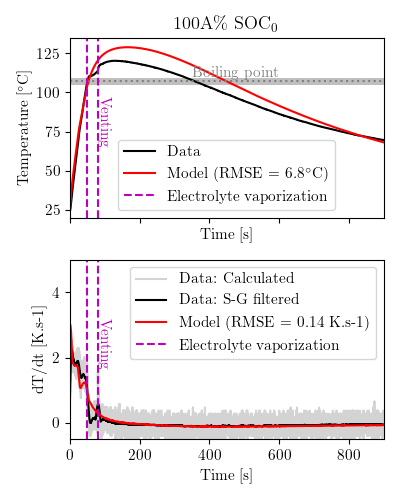

0.13650373272456365


In [25]:
# plot 
# h = 15 
# Cp = 1.27182189
# h = 15.06073745+2
# Cp = 1.1633148
# h = 17.08215933 #100% dT loss function
# Cp = 1.2349498
# h = 15.09329108 #100%F dT loss function
# Cp = 1.05618108
# h = 17.0676768 # 75% dT loss function 
# Cp = 0.97413164
# [15.06073745  1.1633148] # w= 0.25 for high temp

h = 16.67261639           
Cp =  1.27305988 - 0.1
solution = sim_thermal_nondim(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
T_bp = 107
T = solution["Volume-averaged cell temperature [K]"]
rmse_T = np.sqrt(np.mean(np.square(data.Temp- (T(data.t)-273.15))))

dTdt_data = np.diff(data.Temp)/np.diff(data.t)
dT_filtered = signal.savgol_filter(dTdt_data, 10*16,3)
T = solution['Volume-averaged cell temperature [K]']
dTdt_sim = np.diff(T(data.t[0:-1]))/np.diff(data.t[0:-1])
RMSE_dT = np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim)))

# plot 
fig, ax= plt.subplots(2, 1, figsize=(4, 5), sharex=True) #, constrained_layout=True
ax = ax.flatten()

ax[0].plot(data.t, data.Temp, color = 'k', label = "Data")
ax[0].plot(data.t, T(data.t)-273.15, color = 'r', label = "Model (RMSE = " + str(np.round(rmse_T, 1)) + '$^\circ$C)')
ax[0].plot([0,t_end], [T_bp]*2, color = 'gray', linestyle = ':')
ax[0].axhspan(T_bp-2.2, T_bp+2.2, facecolor ='gray', alpha = 0.5) 
ax[0].annotate('Boiling point', xy=(t_end/2-100, T_bp+3), color = 'gray')

ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Temperature [$^\circ$C]")
# ax[0].legend()
ax[0].set_title(SOC_name + "\% SOC$_0$")
ax[0].set_xlim([0,t_end])
ax[0].set_ylim([20,135])

ax[1].plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Data: Calculated")
ax[1].plot(data.t[0:-1], dT_filtered, color = 'k', label = "Data: S-G filtered")
ax[1].plot(data.t[0:-2], dTdt_sim, color = 'r', label = "Model (RMSE = " + str(round(RMSE_dT, 2)) + " K.s-1)")
ax[1].set_ylabel("dT/dt [K.s-1]")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylim([-0.5, 5])
ax[1].set_xlim([0,t_end])
# ax[1].legend()

t_boiling = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[0]
if SOC_0 ==1:
    t_vaps = [t_boiling, t_vent]
else: 
    t_boiling2 = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[-1]
    t_vaps = [t_boiling, t_boiling2]

for axs in fig.get_axes():
    for i, t_vap in enumerate(t_vaps):
        ylims = axs.get_ylim()
        if i ==0:
            axs.plot([t_vap]*2, list(ylims), color = 'm', linestyle = '--', label = 'Electrolyte vaporization') #(T$>$' + str(T_bp) + '$^\circ$C)
        else:
            axs.plot([t_vap]*2, list(ylims), color = 'm', linestyle = '--')
        axs.set_ylim(ylims) # keep original limits
        axs.legend()
    if (SOC_0 ==1):# and (l == len(solutions)-1):
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
        # ylims = axs.get_ylim()
        # axs.annotate('Boiling', xy=(t_boiling-35, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
        # axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
        axs.annotate('Venting', xy=(t_vent, np.diff(ylims)*0.4+ ylims[0]), rotation=-90, color = 'm')
        axs.set_ylim(ylims) # keep original limits
            
plt.tight_layout()
# fig.suptitle(str(int(1*100)) + "\% SOC$_0$", y=1, x = 0.55)
# plt.savefig('./figs/' + SOC_name + 'ESC_thermal_fit.eps', format='eps', dpi = 300)
plt.show()
print(RMSE_dT)


In [26]:
t_dT = (data.t[0:-1]>t_vaps[0]) & (data.t[0:-1]<t_vaps[1])
print(np.trapz(dTdt_data[t_dT]-dTdt_sim[t_dT[0:-1]], data.t[0:-1][t_dT]))
print(np.sqrt(np.mean(np.square(data.Temp[data.t<t_vaps[0]]- (T(data.t[data.t<t_vaps[0]])-273.15)))))

-8.943927005850366
4.024021518008709


# Create thermal model

# Dimensional 

In [86]:
h =  19.12756173 #0.4865/0.025549 #0.009 # 10 [19.12756173  1.18576391]
Cp = 1.18576391 #219.2578/0.104/1100  # 1.25

chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2, 
    "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Cell open circuit voltage [V]": ocv,
}, check_already_exists = False)

## Check that model runs

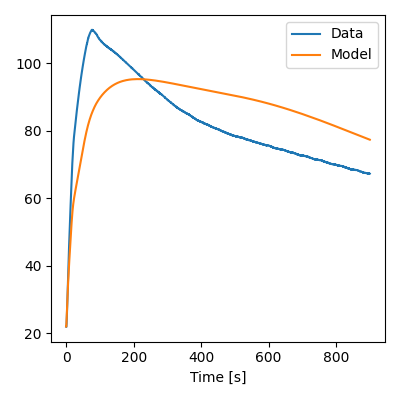

In [87]:
def sim_thermal(h,Cp):    
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)
    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating [W]")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature [K]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged total heating [W]": Q_vol_av, 
        "Volume-averaged cell temperature [K]": T_vol_av,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    liion = pybamm.LithiumIonParameters()
    cell_surface_area = param.evaluate(liion.A_cooling) # [m2]
    cell_volume = param.evaluate(liion.V_cell) # [m3]
    h_total = param.evaluate(thermal.h_total_dim) # [W.m-2.K-1]
    rho = param.evaluate(thermal.rho_eff_dim(T_vol_av)) # [J.m-3.K-1]
    T_amb = T_amb_0+273.15
    total_cooling_coefficient = -h_total

    # RHS
    model.rhs = {
        T_vol_av: 1/(rho * cell_volume)* Q_vol_av + total_cooling_coefficient * cell_surface_area / (rho * cell_volume) * (T_vol_av - T_amb)
    }
    # print(rho * cell_volume)
    # print(total_cooling_coefficient * cell_surface_area)
    # set initial conditions
    T_init = T_amb
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = data.I*(ocv(data.SOC)-data.V)

    # solve
    sim = pybamm.Simulation(model)
    for i,(t, q) in enumerate(zip(data.t[0:-1], Q_data[0:-1])):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged total heating [W]": q}
        sim.step(dt, external_variables=external_variables)
    
    return sim

sim = sim_thermal(15, 1.18576391) #19.12756173,  1.18576391
solution = sim.solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
Q = solution["Volume-averaged total heating [W]"].entries

# plot 
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(data.t, data.Temp)
# ax.plot(data.t, Q_data)
ax.plot(t_sol, T)
ax.set_xlabel("Time [s]")
ax.legend(["Data", "Model"], loc="best")

plt.tight_layout()
plt.show()


## Set up loss function

In [88]:
def loss_T(k:np.ndarray): 
    h = k[0]
    Cp = k[1]
    solution = sim_thermal(h,Cp).solution

    # calculate squared sum for rest period
    T = solution['Volume-averaged cell temperature [K]'] 
    # loss_T = np.sum(np.square(data.Temp- (T(data.t)-273.15)))
    # loss_T = np.linalg.norm(data.Temp- (T(data.t)-273.15))
    loss_T = np.linalg.norm(np.diff(data.Temp) - np.diff(T(data.t)))
    return np.array([loss_T])

# test function
print(loss_T(np.array([20, 1])))

[2.32156342]


## Fit thermal parameters

In [ ]:
# # define sim parameters 
# # Fit thermal params
# [19.12756173  1.18576391]
k0 = np.array([5,1]) #[h, k_cp] cp = cp0*k_cp
lb = np.array([5,0.1])
ub = np.array([50,2])
k = dfols.solve(loss_T, k0, bounds = (lb,ub), rhoend=1e-4)

# update fitted thermal params
h = k.x[0]
Cp = k.x[1]
solution = sim_thermal(h,Cp)
solution = sim_thermal(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states

print(k.x)


## Plot data vs model

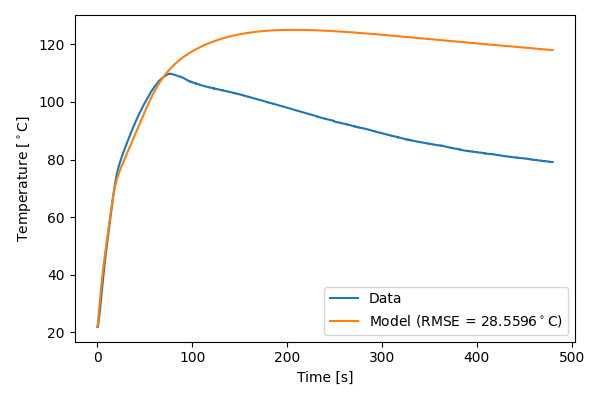

In [ ]:
# plot 
h = 
Cp = 
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
Q = solution["Volume-averaged total heating [W]"].entries

rmse_T = np.sqrt(np.mean(np.square(data.Temp- T)))

solution = sim_thermal(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
Q = solution["Volume-averaged total heating [W]"].entries


fig, ax= plt.subplots(1, 1, figsize=(6, 4))
ax.plot(data.t, data.Temp, label = "Data")
ax.plot(t_sol, T, label = "Model (RMSE = " + str(np.round(rmse_T, 4)) + '$^\circ$C)' )
ax.set_xlabel("Time [s]")
ax.set_ylabel("Temperature [$^\circ$C]")
ax.legend()

plt.tight_layout()
plt.show()

# Dimensional with latent heat of vaporization

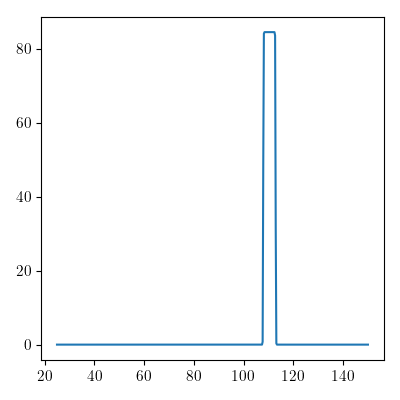

In [39]:
def P_sat(T):
    P_dmc = 10**(6.4338-1413.0/(T-44.25))
    P_ec = 10**(6.4897-1836.57/(T-102.23))
    P = 0.3*P_ec + 0.7*P_dmc 
    return P

electrolyte_boiling_pt = 0.3*110+0.7*107
h_vap = .3*60+.7*34.6
x = np.linspace(25,150, 500)
y = ((np.tanh(10*(x-electrolyte_boiling_pt))+1)*(-np.tanh(10*(x-(electrolyte_boiling_pt+5)))+1))*h_vap/2

# plot 
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(x,y)

plt.tight_layout()
plt.show()


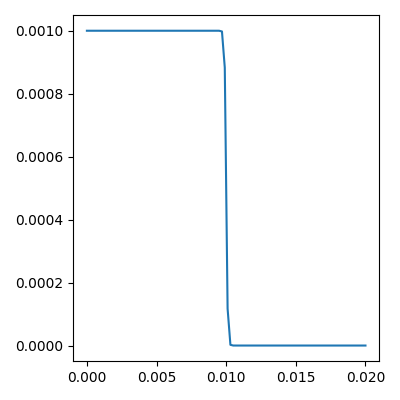

In [10]:
thermal = pybamm.thermal_parameters
total_electrolyte_mass = 10e-3
M_e = param.evaluate(thermal.M_e)
m_e_loss = np.linspace(0, total_electrolyte_mass*2, 100)
m_e_loss_rate = 1e-3/2*(-np.tanh((m_e_loss-total_electrolyte_mass)*10000)+1)

# plot 
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(m_e_loss,m_e_loss_rate)

plt.tight_layout()
plt.show()

In [11]:
def sim_thermal_vap(h,Cp):    
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Electrolyte boiling point [K]": (0.3*110+0.7*107) + 273.15,
        "Electrolyte heat of vaporization [J.mol-1]": (.3*60+.7*34.6)*1000, 
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)
    
    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating [W]")
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    x_sei = pybamm.Variable("Fraction of Li in SEI")
    delta_sigma = pybamm.Variable("Cell expansion stress [kPa]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged total heating [W]": Q_vol_av, 
        "Volume-averaged cell temperature [K]": T_vol_av,
        "Fraction of Li in SEI": x_sei,
        "Cell expansion stress [kPa]": delta_sigma,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    liion = pybamm.LithiumIonParameters()
    T_amb = T_amb_0+273.15

    # SEI DECOMPOSITION SUBMODEL
    k_b = pybamm.Scalar(constants.k)
    rho_n_dim = param["Negative electrode density [kg.m-3]"]
    r_sei_dimensional = (
    -param.evaluate(thermal.A_sei)* x_sei* pybamm.exp(-param.evaluate(thermal.E_sei) / (k_b * T_vol_av)))  # units 1/s
    m_an = rho_n_dim * param.evaluate(liion.L_y) * param.evaluate(liion.L_z) * param.evaluate(liion.n.L)
    Q_exo_sei = -m_an * param.evaluate(thermal.h_sei) * r_sei_dimensional 

    model.variables.update({
            "SEI decomposition reaction rate [s-1]": r_sei_dimensional,
            "SEI decomposition heating [W]": Q_exo_sei,
        })
    
    # VENTING SUBMODEL
    m_an = param.evaluate(thermal.m_an)
    x_sei_0 = param.evaluate(thermal.x_sei_0)
    M_C6 = param.evaluate(thermal.M_an)
    V_head_0 = param.evaluate(thermal.V_head_0)
    A_surf = param.evaluate(thermal.A_surf)
    L = param.evaluate(thermal.L_poron)
    E = param.evaluate(thermal.E_poron)
    alpha_cell = param.evaluate(thermal.alpha_cell)
    P_crit = param.evaluate(thermal.P_crit)
    sigma_0 = param.evaluate(thermal.sigma_0)
    P_atm = param.evaluate(thermal.P_atm)
    M_e = param.evaluate(thermal.M_e)
    # rho_e = thermal.rho_e
    # m_e_0 = thermal.m_e_0
    delta_d = L/E*delta_sigma
    delta_T = T_vol_av-T_amb
    V_head = V_head_0 + A_surf*(delta_d-alpha_cell*delta_T)   
    P_sat_e = P_sat(T_vol_av) 
    P_sat_ref = P_sat(T_amb)
    n_CO2 = m_an*(x_sei_0 - x_sei)/(2*M_C6)
    P_CO2 = (n_CO2*constants.R*T_vol_av/V_head/1000) #kPa
    P_total = P_CO2 + P_sat_e 
    n_e_vap = P_sat_e*1000*V_head/(constants.R*T_vol_av) - P_sat_ref*1000*V_head_0/(constants.R*T_amb)
    m_e_loss = pybamm.maximum(n_e_vap*M_e,0)  # [kg]

    model.variables.update({
        "Mass of electrolyte lost [kg]": m_e_loss,
        "Moles of electrolyte lost [mol]": n_e_vap,
    })

    # HEAT OF VAPORIZATION
    cell_surface_area = param.evaluate(liion.A_cooling) # [m2]
    cell_volume = param.evaluate(liion.V_cell) # [m3]
    h_total = param.evaluate(thermal.h_total_dim) # [W.m-2.K-1]
    rho = param.evaluate(thermal.rho_eff_dim(T_vol_av)) # [J.m-3.K-1]
    total_cooling_coefficient = -h_total
    electrolyte_boiling_pt = 110 + 273.15
    h_vap = (.3*60+.7*34.6)*1000
    # H_vap = (pybamm.tanh(10*(T_vol_av-(electrolyte_boiling_pt)))+1)*h_vap/2 # "turn on" vaporization if T is above the boiling pt
    H_vap = h_vap # "turn on" vaporization if T is above the boiling pt

    total_electrolyte_mass = 1e-3 #[kg]
    M_e = param.evaluate(thermal.M_e)
    # m_e_loss_rate = (-pybamm.tanh(10*(T_vol_av-(electrolyte_boiling_pt+15)))+1)
    # n_e_loss_rate = pybamm.Symbol(n_e_vap).diff()
    # Q_cool_vap = -H_vap*pybamm.maximum(1e-3 - m_e_loss,0)/M_e    Q_cool_vap = -H_vap*pybamm.maximum(1e-3 - m_e_loss,0)/M_e
    dTdt = (Q_vol_av + total_cooling_coefficient * cell_surface_area* (T_vol_av - T_amb)) / (rho * cell_volume)
    # dndt = -(P_sat_e*1000*V_head/(constants.R*T_vol_av))**-2*dTdt
    # dndt = pybamm.Symbol.diff(n_e_vap,pybamm.t) # error about derivative of variable in rhs
    dndt = (P_sat_e*1000*V_head/(constants.R*T_vol_av))*dTdt

    # Q_cool_vap = -H_vap*m_e_loss/M_e
    Q_cool_vap = -H_vap*pybamm.maximum(dndt,0)

    model.variables.update({
        "Total heat of vaporization [W]": Q_cool_vap,
    })

    # RHS
    model.rhs = {
        T_vol_av: (Q_vol_av + total_cooling_coefficient * cell_surface_area* (T_vol_av - T_amb) + Q_cool_vap + Q_exo_sei) / (rho * cell_volume),
        x_sei: r_sei_dimensional,
        # m_e_loss: m_e_loss_rate,
    }
    # print(rho * cell_volume)
    # print(total_cooling_coefficient * cell_surface_area)
    # set initial conditions
    T_init = T_amb
    model.initial_conditions = {
        T_vol_av: pybamm.Scalar(T_init),
        x_sei: param.evaluate(thermal.x_sei_0),
        delta_sigma: pybamm.Scalar(0),
        # m_e_loss:pybamm.Scalar(0),
        }

    model.algebraic = {
        delta_sigma: delta_sigma - pybamm.maximum(P_total-sigma_0-P_atm, E*alpha_cell*delta_T/L),
        }
    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = data.I*(ocv(data.SOC)-data.V)

    # solve
    sim = pybamm.Simulation(model)
    for i,(t, q) in enumerate(zip(data.t[0:-1], Q_data[0:-1])):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged total heating [W]": q}
        sim.step(dt, external_variables=external_variables)
    
    return sim

# sim_vap = sim_thermal_vap(19.12756173,  1.18576391)
h = 19.12756173-3
Cp = 1
# sim = sim_thermal(h,  Cp)
# solution = sim.solution
# t, y = solution.t, solution.y  # get solution times and states
# T = solution["Volume-averaged cell temperature [K]"].entries-273.15 
# Q = solution["Volume-averaged total heating [W]"].entries

sim_vap = sim_thermal_vap(h,Cp)
solution_vap = sim_vap.solution
t_vap, y_vap = solution_vap.t, solution_vap.y  # get solution times and states
T_vap = solution_vap["Volume-averaged cell temperature [K]"].entries-273.15  
Q_vap = solution_vap["Volume-averaged total heating [W]"].entries


NameError: name 't' is not defined

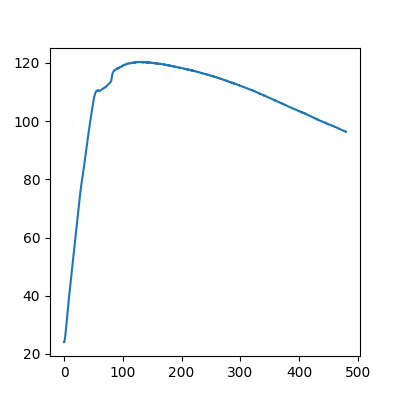

In [ ]:
# plot 
Q_data = data.I*(ocv(data.SOC)-data.V)
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(data.t, data.Temp, label = "Data")
ax.plot(t, T, label = "Nominal")
ax.plot(t_vap, T_vap, label = "with vaporization")

ax1 = plt.twinx(ax)
m_e_loss = solution_vap["Mass of electrolyte lost [kg]"].entries*1000 
H_vap_total = solution_vap["Total heat of vaporization [W]"].entries
# ax1.plot(t_sol, m_e_loss, color="grey", linestyle = '--')
ax1.plot(t_sol, H_vap_total, color="grey", linestyle = '--', label = "$Q_{vap,total}$")
# ax1.plot(data.t, Q_data, color="m", linestyle = '--', label = "$Q_{ohmic}$")

ax.set_xlabel("Time [s]")
ax.legend(loc="right")
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

## References

The relevant papers for this notebook are:

In [ ]:
pybamm.print_citations()

[1] Weilong Ai, Ludwig Kraft, Johannes Sturm, Andreas Jossen, and Billy Wu. Electrochemical thermal-mechanical modelling of stress inhomogeneity in lithium-ion pouch cells. Journal of The Electrochemical Society, 167(1):013512, 2019. doi:10.1149/2.0122001JES.
[2] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[3] Rutooj Deshpande, Mark Verbrugge, Yang-Tse Cheng, John Wang, and Ping Liu. Battery cycle life prediction with coupled chemical degradation and fatigue mechanics. Journal of the Electrochemical Society, 159(10):A1730, 2012. doi:10.1149/2.049210jes.
[4] Charles R. Harris, K. Jarrod Millman, Stéfan J. van der Walt, Ralf Gommers, Pauli Virtanen, David Cournapeau, Eric Wieser, Julian Taylor, Sebastian Berg, Nathaniel J. Smith, and others. Array programming with NumPy. Nature, 585(782